In [1]:
import os
import math
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("wangszhi/xau-1day-gold-datasets")

# print("Path to dataset files:", path)

In [ ]:
# 1) Load data
path = "/kaggle/input/datasets/wangszhi/xau-1day-gold-datasets/XAU_1d_data.csv"
if not os.path.exists(path):
    path = "XAU_1d_data.csv"

df = pd.read_csv(path, sep=";")
print(df.head())
print(df.columns)

df["Date"] = pd.to_datetime(df["Date"], format="%Y.%m.%d %H:%M", errors="coerce")

numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().sort_values("Date").reset_index(drop=True)
print("Rows after basic cleaning:", len(df))

               Date   Open   High    Low  Close  Volume
0  2004.06.11 00:00  384.0  384.8  382.8  384.1     272
1  2004.06.14 00:00  384.3  385.8  381.8  382.8    1902
2  2004.06.15 00:00  382.8  388.8  381.1  388.6    1951
3  2004.06.16 00:00  387.1  389.8  382.6  383.8    2014
4  2004.06.17 00:00  383.6  389.3  383.0  387.6    1568
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Rows after basic cleaning: 5516


In [4]:
# # 2) Feature engineering
# #    Target = % change of Close from yesterday to today
# def build_features(data: pd.DataFrame) -> pd.DataFrame:
#     data = data.copy()
#     # Input features
#     data["body_pct"] = (data["Close"] - data["Open"]) / data["Open"]
#     data["range_pct"] = (data["High"] - data["Low"]) / data["Open"]
#     data["close_return_1"] = (data["Close"].pct_change()).shift(1)
#     data["open_gap_pct"] = (data["Open"] - data["Close"].shift(1)) / data["Close"].shift(1)
#     data["volume_return_1"] = data["Volume"].pct_change()
#     # Target: daily % change of close vs previous close
#     data["target_pct"] = data["Close"].pct_change()
#     # Clean inf / NaN
#     data = data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
#     return data 

# df_feat = build_features(df)

# feature_cols = [ "Open", "High", "Low", "Close", "Volume", "body_pct", "range_pct", "close_return_1", "open_gap_pct", "volume_return_1" ]
# target_col = "target_pct"

# print("Feature columns:", feature_cols)
# print("Prepared rows:", len(df_feat))
# print(df_feat[["Date", "Close", "target_pct"]].head(10))

In [5]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:

    data = data.copy()



    data["body_pct"] = ((data["Close"] - data["Open"]) / data["Open"]).shift(1)

    data["range_pct"] = ( (data["High"] - data["Low"]) / data["Open"]).shift(1)

    data["close_return_1"] = (data["Close"].pct_change()).shift(1)

    data["open_gap_pct"] = ((data["Open"] - data["Close"].shift(1))/ data["Close"].shift(1)).shift(1)

    data["volume_return_1"] = ( data["Volume"].pct_change()).shift(1)


    data["target_pct"] = (data["Close"].pct_change())


    data = (data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True))

    return data

df_feat = build_features(df)

feature_cols = [ "Open", "High", "Low", "Close", "Volume", "body_pct", "range_pct", "close_return_1", "open_gap_pct", "volume_return_1" ]
target_col = "target_pct"
print("Feature columns:", feature_cols)
print("Prepared rows:", len(df_feat))
print(df_feat[["Date", "Close", "target_pct"]].head(10))

Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'body_pct', 'range_pct', 'close_return_1', 'open_gap_pct', 'volume_return_1']
Prepared rows: 5514
        Date  Close  target_pct
0 2004-06-15  388.6    0.015152
1 2004-06-16  383.8   -0.012352
2 2004-06-17  387.6    0.009901
3 2004-06-18  394.3    0.017286
4 2004-06-21  393.1   -0.003043
5 2004-06-22  394.1    0.002544
6 2004-06-23  395.6    0.003806
7 2004-06-24  401.1    0.013903
8 2004-06-25  401.1    0.000000
9 2004-06-28  399.8   -0.003241


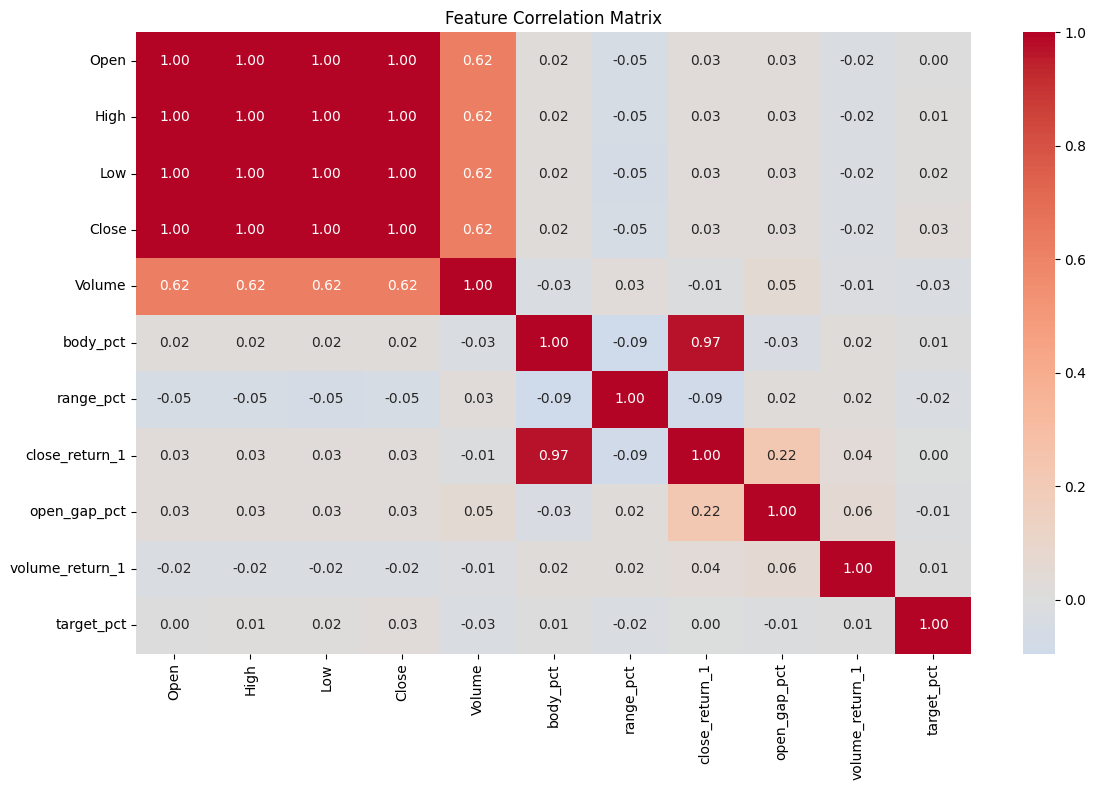


Correlation with target_pct:

target_pct         1.000000
Close              0.025824
Low                0.016540
High               0.014035
body_pct           0.005460
volume_return_1    0.005208
Open               0.004176
close_return_1     0.003531
open_gap_pct      -0.007372
range_pct         -0.024533
Volume            -0.028103
Name: target_pct, dtype: float64


In [6]:
# =========================
# Correlation Analysis
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = feature_cols + [target_col]

corr_matrix = df_feat[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


# Correlation with target only
target_corr = (
    corr_matrix[target_col]
    .sort_values(ascending=False)
)

print("\nCorrelation with target_pct:\n")
print(target_corr)

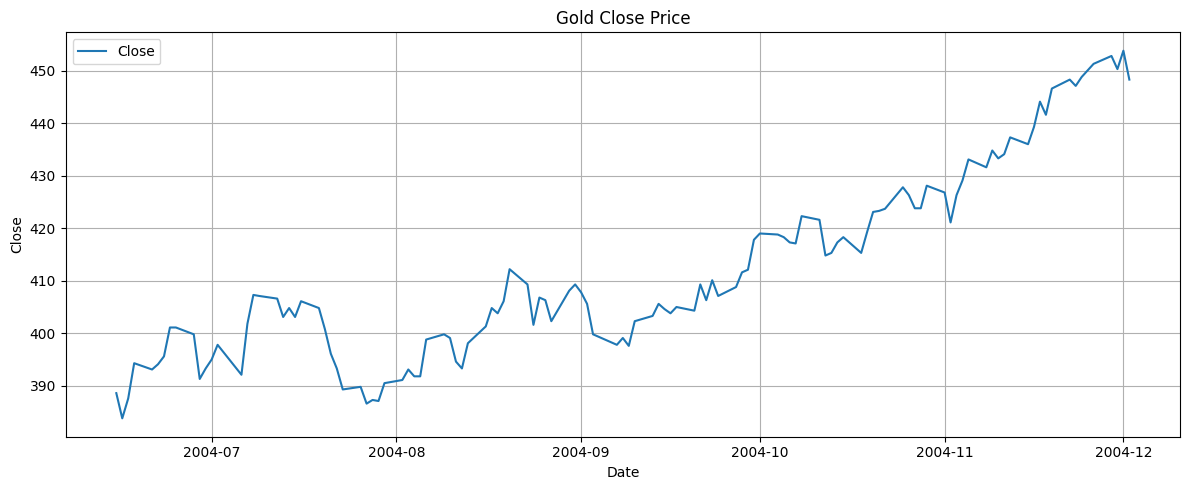

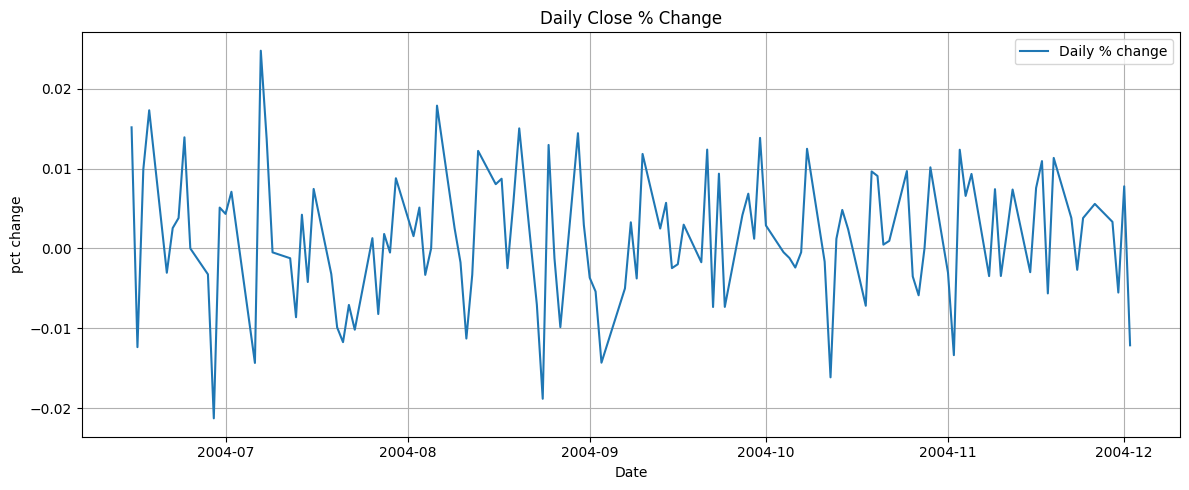

In [7]:

# 3) Quick visualization
plt.figure(figsize=(12, 5))
plt.plot(df_feat["Date"].iloc[:120], df_feat["Close"].iloc[:120], label="Close")
plt.title("Gold Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_feat["Date"].iloc[:120], df_feat["target_pct"].iloc[:120], label="Daily % change")
plt.title("Daily Close % Change")
plt.xlabel("Date")
plt.ylabel("pct change")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

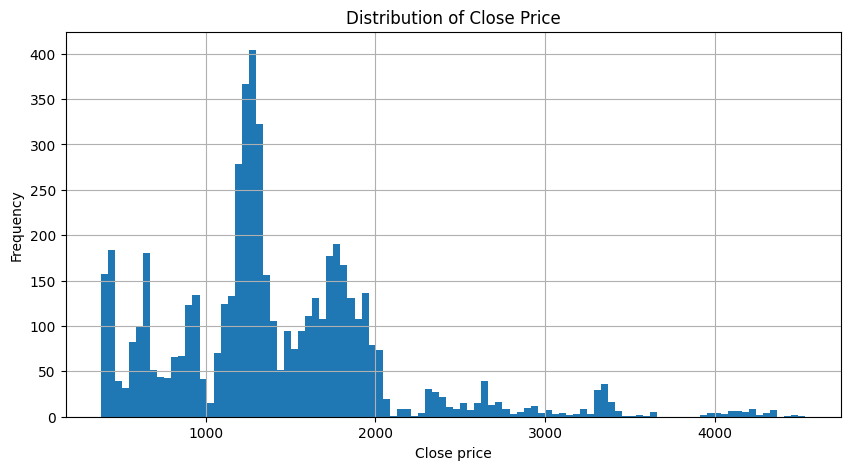


Target Statistics:

count    5514.000000
mean     1405.977291
std       651.516691
min       383.800000
25%      1062.815000
50%      1300.065000
75%      1743.677500
max      4531.170000
Name: Close, dtype: float64


In [8]:
# Target Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    df_feat['Close'],
    bins=100
)

plt.title("Distribution of Close Price")
plt.xlabel("Close price")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

# Basic statistics
print("\nTarget Statistics:\n")
print(df_feat['Close'].describe())

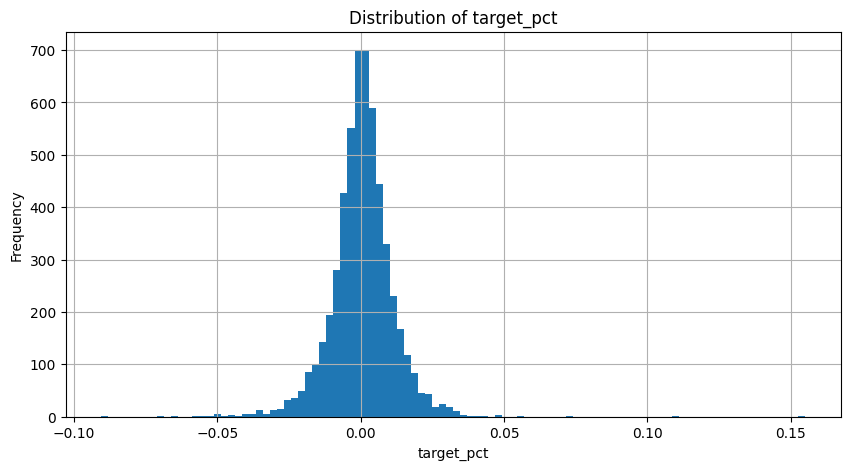


Target Statistics:

count    5514.000000
mean        0.000500
std         0.010996
min        -0.090621
25%        -0.004847
50%         0.000591
75%         0.006158
max         0.155080
Name: target_pct, dtype: float64


In [9]:
# Target Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    df_feat[target_col],
    bins=100
)

plt.title("Distribution of target_pct")
plt.xlabel("target_pct")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

# Basic statistics
print("\nTarget Statistics:\n")
print(df_feat[target_col].describe())

In [10]:

# 4) Chronological split + scaling
lookback = 7
horizon = 1  # predict the next day
train_ratio = 0.80
val_ratio = 0.1
test_ratio = 0.1
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
n_rows = len(df_feat)

all_sample_starts = np.arange(0, n_rows - lookback)  # target index = start + lookback
target_indices = all_sample_starts + lookback

train_target_end = int(n_rows * train_ratio)
val_target_end = int(n_rows * (train_ratio + val_ratio))

train_starts = all_sample_starts[target_indices < train_target_end]
val_starts = all_sample_starts[(target_indices >= train_target_end) & (target_indices < val_target_end)]
test_starts = all_sample_starts[target_indices >= val_target_end]
print(f"Total rows: {n_rows}")
print(f"Train samples: {len(train_starts)}")
print(f"Val samples:   {len(val_starts)}")
print(f"Test samples:  {len(test_starts)}")
feature_cols = [ "range_pct", "close_return_1", "open_gap_pct", "volume_return_1" ]

train_feature_rows = df_feat.iloc[:train_target_end][feature_cols].values.astype(np.float32)
feature_mean = train_feature_rows.mean(axis=0)
feature_std = train_feature_rows.std(axis=0)
feature_std[feature_std == 0] = 1.0

all_features = df_feat[feature_cols].values.astype(np.float32)
all_features = (all_features - feature_mean) / feature_std

all_target_pct = df_feat[target_col].values.astype(np.float32)
all_close = df_feat["Close"].values.astype(np.float32)
all_dates = df_feat["Date"].values

print("Feature mean shape:", feature_mean.shape)
print("Feature std shape:", feature_std.shape)

Total rows: 5514
Train samples: 4404
Val samples:   551
Test samples:  552
Feature mean shape: (4,)
Feature std shape: (4,)


In [11]:
# 5) Dataset
class GoldWindowDataset(Dataset):
    def __init__(self, features, target_pct, close_prices, dates, sample_starts, lookback=7):
        self.features = features.astype(np.float32)
        self.target_pct = target_pct.astype(np.float32)
        self.close_prices = close_prices.astype(np.float32)
        self.dates = dates
        self.sample_starts = np.asarray(sample_starts, dtype=np.int64)
        self.lookback = lookback
    def __len__(self):
        return len(self.sample_starts)
    def __getitem__(self, idx):
        start = self.sample_starts[idx]
        end = start + self.lookback  # target index = next day after the window
        x = self.features[start:end]                # [lookback, num_features]
        y = self.target_pct[end]                   # pct change on the target day
        base_close = self.close_prices[end - 1]    # close of the last input day
        true_close = self.close_prices[end]        # actual close on the target day
        target_date = self.dates[end]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor([y], dtype=torch.float32),
            torch.tensor([base_close], dtype=torch.float32),
            torch.tensor([true_close], dtype=torch.float32),
            torch.tensor(end, dtype=torch.long),
        )
train_dataset = GoldWindowDataset(all_features, all_target_pct, all_close, all_dates, train_starts, lookback=lookback)
val_dataset = GoldWindowDataset(all_features, all_target_pct, all_close, all_dates, val_starts, lookback=lookback)
test_dataset = GoldWindowDataset(all_features, all_target_pct, all_close, all_dates, test_starts, lookback=lookback)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=False)

print("Example batch shapes:")
xb, yb, baseb, trueb, idxb = next(iter(train_loader))
print(xb.shape, yb.shape, baseb.shape, trueb.shape, idxb.shape)

Example batch shapes:
torch.Size([64, 7, 4]) torch.Size([64, 1]) torch.Size([64, 1]) torch.Size([64, 1]) torch.Size([64])


In [12]:
# 6) GRU + temporal attention model
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, gru_out):
        # gru_out: [B, T, H]
        attn_logits = self.score(gru_out).squeeze(-1)  # [B, T]
        attn_weights = torch.softmax(attn_logits, dim=1)  # [B, T]
        context = torch.sum(gru_out * attn_weights.unsqueeze(-1), dim=1)  # [B, H]
        return context, attn_weights

class GRUAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn = TemporalAttention(hidden_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        gru_out, _ = self.gru(x)            # [B, T, H]
        context, attn_weights = self.attn(gru_out)
        out = self.head(context)            # [B, 1]
        return out, attn_weights

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = GRUAttentionModel(
    input_size=len(feature_cols),
    hidden_dim=64,
    num_layers=1,
    dropout=0.15,
).to(device)

criterion = nn.SmoothL1Loss()   # stable for percentage targets
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print(model)

Device: cuda
GRUAttentionModel(
  (gru): GRU(4, 64, batch_first=True)
  (attn): TemporalAttention(
    (score): Linear(in_features=64, out_features=1, bias=True)
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [13]:
# 7) Train / evaluate
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for x, y, *_ in loader:
            x = x.to(device)
            y = y.to(device)
            pred, _ = model(x)
            loss = criterion(pred, y)

            bs = x.size(0)
            total_loss += loss.item() * bs
            total_count += bs

    return total_loss / max(total_count, 1)
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_count = 0
    for x, y, *_ in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred, _ = model(x)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_count += bs
    return total_loss / max(total_count, 1)
num_epochs = 100
patience = 8
best_val_loss = float("inf")
best_state = None
bad_epochs = 0
train_losses = []
val_losses = []
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch [{epoch:02d}/{num_epochs}] | train={train_loss:.6f} | val={val_loss:.6f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model with val loss = {best_val_loss:.6f}")

Epoch [01/100] | train=0.002593 | val=0.000081
Epoch [02/100] | train=0.000238 | val=0.000047
Epoch [03/100] | train=0.000144 | val=0.000044
Epoch [04/100] | train=0.000118 | val=0.000045
Epoch [05/100] | train=0.000102 | val=0.000039
Epoch [06/100] | train=0.000094 | val=0.000038
Epoch [07/100] | train=0.000088 | val=0.000038
Epoch [08/100] | train=0.000082 | val=0.000039
Epoch [09/100] | train=0.000076 | val=0.000038
Epoch [10/100] | train=0.000071 | val=0.000038
Epoch [11/100] | train=0.000069 | val=0.000037
Epoch [12/100] | train=0.000068 | val=0.000039
Epoch [13/100] | train=0.000066 | val=0.000038
Epoch [14/100] | train=0.000063 | val=0.000037
Epoch [15/100] | train=0.000062 | val=0.000040
Epoch [16/100] | train=0.000062 | val=0.000038
Epoch [17/100] | train=0.000061 | val=0.000037
Epoch [18/100] | train=0.000061 | val=0.000037
Epoch [19/100] | train=0.000060 | val=0.000037
Epoch [20/100] | train=0.000060 | val=0.000037
Epoch [21/100] | train=0.000060 | val=0.000037
Epoch [22/100

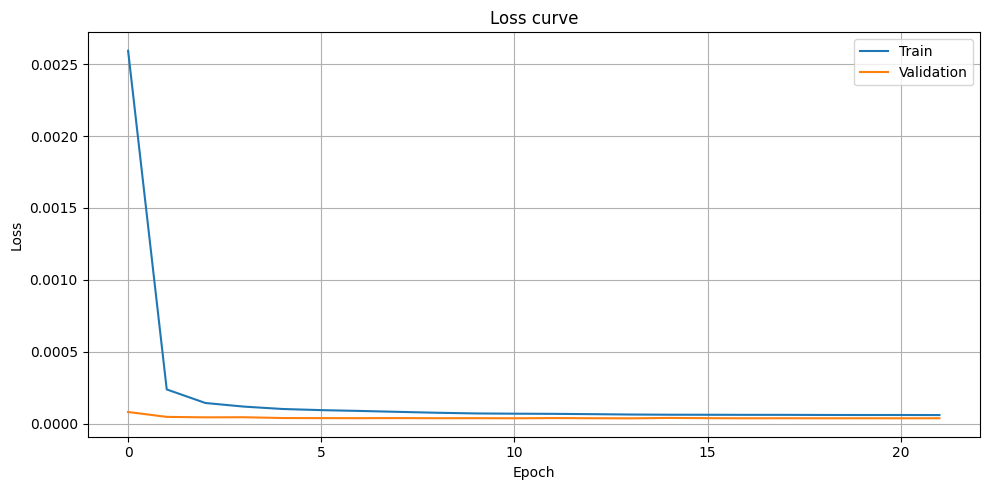

In [14]:
# 8) Loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# =========================
# 9) Prediction: percentage -> next close
# =========================
def predict(model, loader, device):
    model.eval()
    all_pred_pct = []
    all_true_pct = []
    all_base_close = []
    all_true_close = []
    all_target_idx = []

    with torch.no_grad():
        for x, y, base_close, true_close, target_idx in loader:
            x = x.to(device)
            pred_pct, _ = model(x)

            all_pred_pct.append(pred_pct.cpu().numpy())
            all_true_pct.append(y.numpy())
            all_base_close.append(base_close.numpy())
            all_true_close.append(true_close.numpy())
            all_target_idx.append(target_idx.numpy())

    pred_pct = np.concatenate(all_pred_pct, axis=0).reshape(-1)
    true_pct = np.concatenate(all_true_pct, axis=0).reshape(-1)
    base_close = np.concatenate(all_base_close, axis=0).reshape(-1)
    true_close = np.concatenate(all_true_close, axis=0).reshape(-1)
    target_idx = np.concatenate(all_target_idx, axis=0).reshape(-1)

    # Reconstruct next-day close from predicted pct change
    pred_close = base_close * (1.0 + pred_pct)
    true_close_from_pct = base_close * (1.0 + true_pct)

    return {
        "pred_pct": pred_pct,
        "true_pct": true_pct,
        "base_close": base_close,
        "pred_close": pred_close,
        "true_close": true_close,
        "true_close_from_pct": true_close_from_pct,
        "target_idx": target_idx,
    }

test_out = predict(model, test_loader, device)

print("Test samples:", len(test_out["pred_close"]))
print("First 5 predicted pct:", test_out["pred_pct"][:5])
print("First 5 predicted close:", test_out["pred_close"][:5])

Test samples: 552
First 5 predicted pct: [-0.00364866 -0.00275219 -0.00291402 -0.00187738  0.00060839]
First 5 predicted close: [1853.6321 1869.1117 1863.2844 1928.7822 1921.2283]


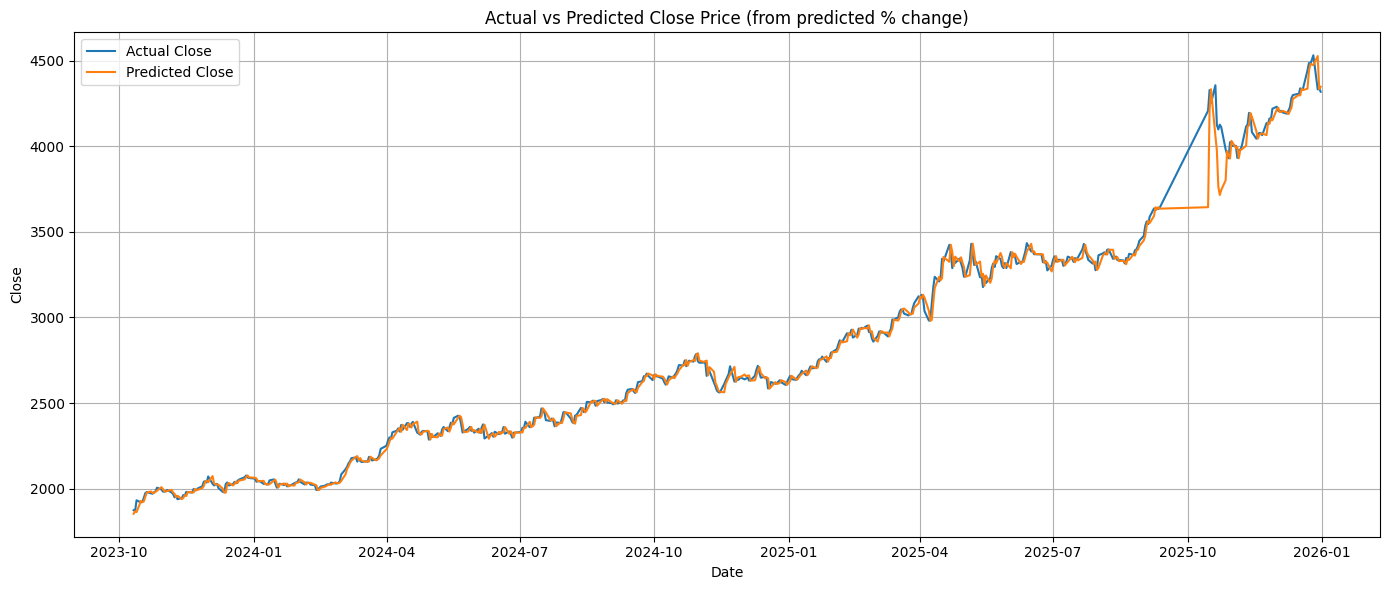

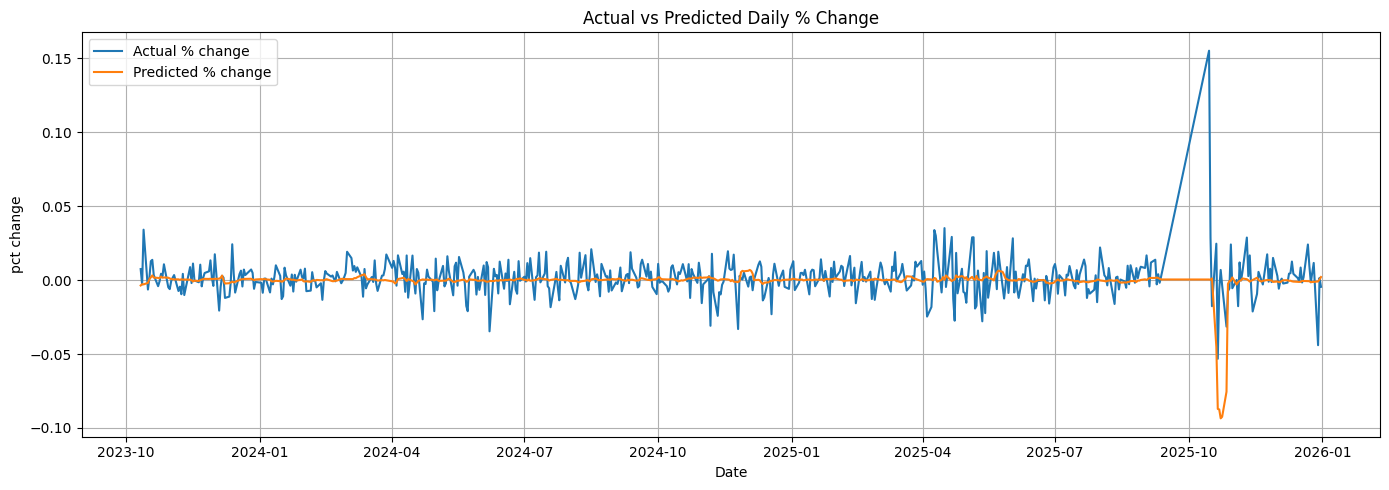

In [16]:
# 10) Plot actual vs predicted close
target_dates = pd.to_datetime(all_dates[test_out["target_idx"]])

plt.figure(figsize=(14, 6))
plt.plot(target_dates, test_out["true_close"], label="Actual Close")
plt.plot(target_dates, test_out["pred_close"], label="Predicted Close")
plt.title("Actual vs Predicted Close Price (from predicted % change)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(target_dates, test_out["true_pct"], label="Actual % change")
plt.plot(target_dates, test_out["pred_pct"], label="Predicted % change")
plt.title("Actual vs Predicted Daily % Change")
plt.xlabel("Date")
plt.ylabel("pct change")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# 11) Optional: show sample prediction table
result_df = pd.DataFrame({
    "Date": target_dates,
    "BaseClose": test_out["base_close"],
    "TruePct": test_out["true_pct"],
    "PredPct": test_out["pred_pct"],
    "TrueClose": test_out["true_close"],
    "PredClose": test_out["pred_close"],
})
print(result_df.head(40))

         Date    BaseClose   TruePct   PredPct    TrueClose    PredClose
0  2023-10-11  1860.420044  0.007445 -0.003649  1874.270020  1853.632080
1  2023-10-12  1874.270020 -0.002956 -0.002752  1868.729980  1869.111694
2  2023-10-13  1868.729980  0.034077 -0.002914  1932.410034  1863.284424
3  2023-10-16  1932.410034 -0.006391 -0.001877  1920.060059  1928.782227
4  2023-10-17  1920.060059  0.001557  0.000608  1923.050049  1921.228271
5  2023-10-18  1923.050049  0.012777  0.001898  1947.619995  1926.699219
6  2023-10-19  1947.619995  0.013689  0.003167  1974.280029  1953.787231
7  2023-10-20  1974.280029  0.003353  0.001679  1980.900024  1977.593994
8  2023-10-23  1980.900024 -0.004119  0.001468  1972.739990  1983.809082
9  2023-10-24  1972.739990 -0.000867  0.001204  1971.030029  1975.114502
10 2023-10-25  1971.030029  0.004272  0.002408  1979.449951  1975.775635
11 2023-10-26  1979.449951  0.002667  0.001594  1984.729980  1982.605835
12 2023-10-27  1984.729980  0.010671  0.001774  200